Shape: (4424, 37)
Fehlende Werte: 0

Klassenverteilung:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


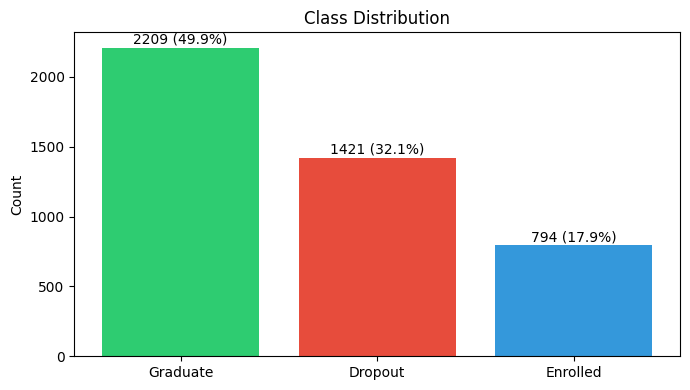

C:\Users\maxim\AppData\Local\Temp\ipykernel_796628\1148068763.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y='Age at enrollment', data=df, palette='Set2')


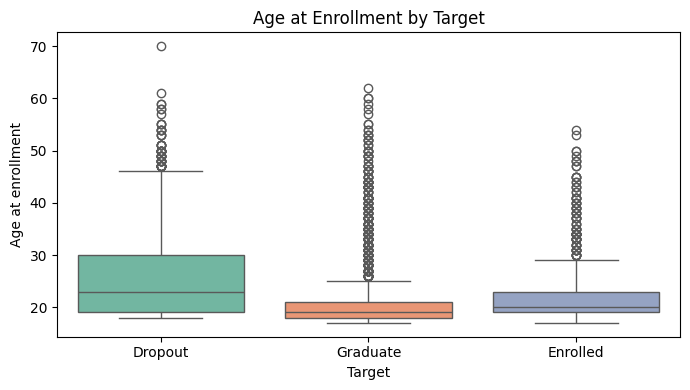

C:\Users\maxim\AppData\Local\Temp\ipykernel_796628\1148068763.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y='Curricular units 1st sem (approved)', data=df, palette='Set2', ax=axes[0])
C:\Users\maxim\AppData\Local\Temp\ipykernel_796628\1148068763.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y='Curricular units 2nd sem (approved)', data=df, palette='Set2', ax=axes[1])


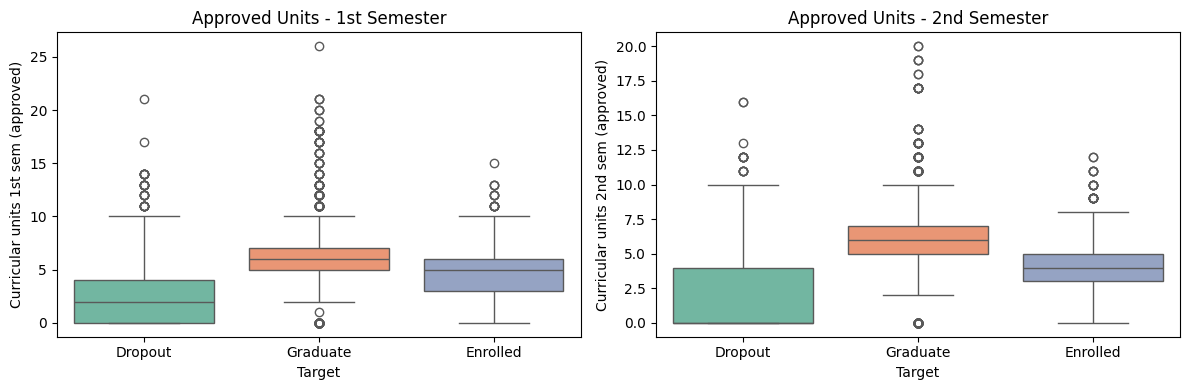

C:\Users\maxim\AppData\Local\Temp\ipykernel_796628\1148068763.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y='Curricular units 1st sem (grade)', data=df, palette='Set2', ax=axes[0])
C:\Users\maxim\AppData\Local\Temp\ipykernel_796628\1148068763.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y='Curricular units 2nd sem (grade)', data=df, palette='Set2', ax=axes[1])


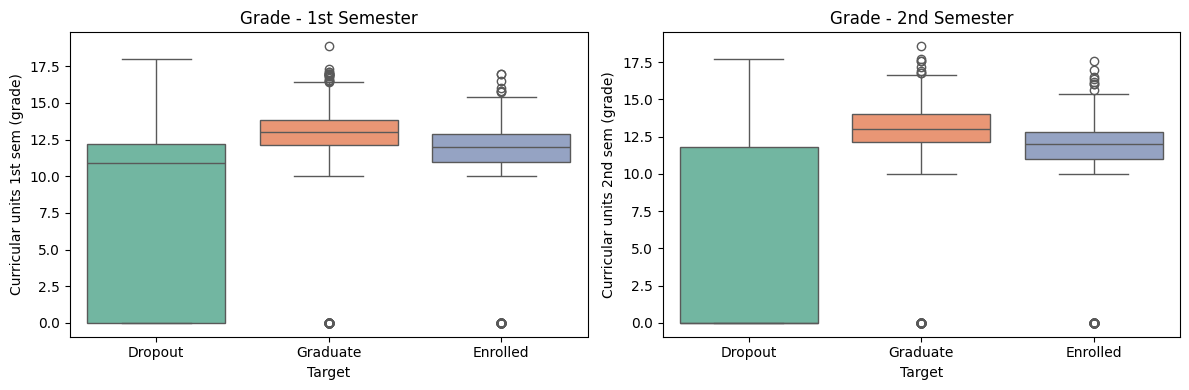

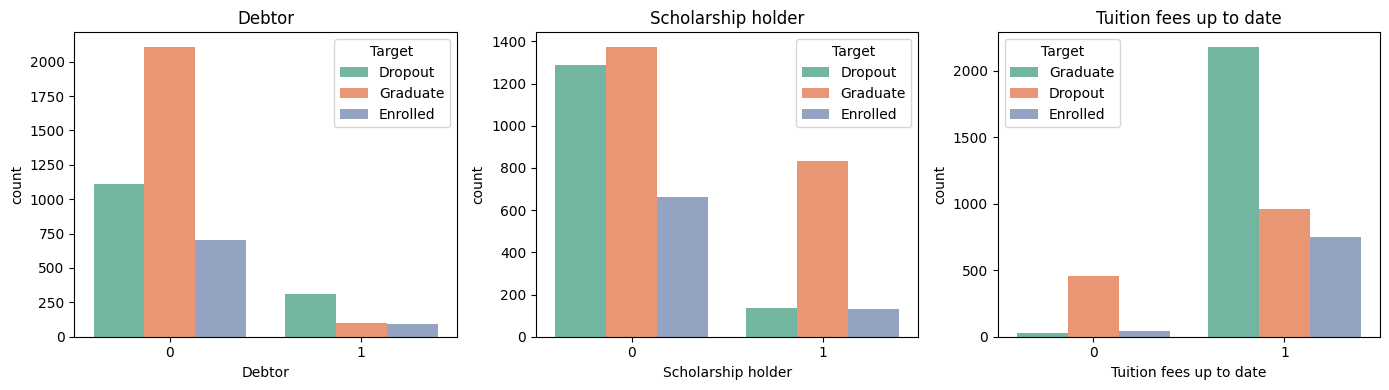

C:\Users\maxim\AppData\Local\Temp\ipykernel_796628\1148068763.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y='Admission grade', data=df, palette='Set2')


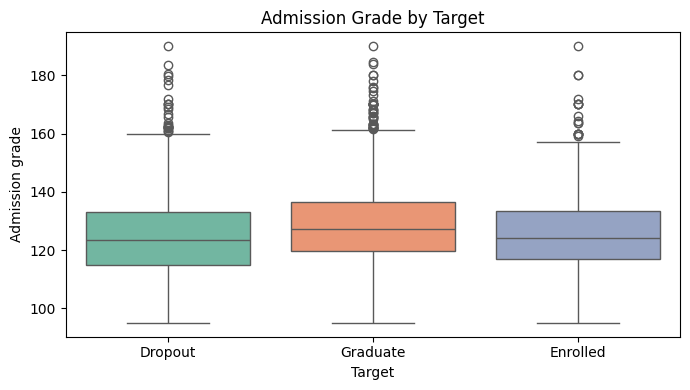

C:\Users\maxim\AppData\Local\Temp\ipykernel_796628\1148068763.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Target', y='Age at enrollment', data=df, palette='Set2')


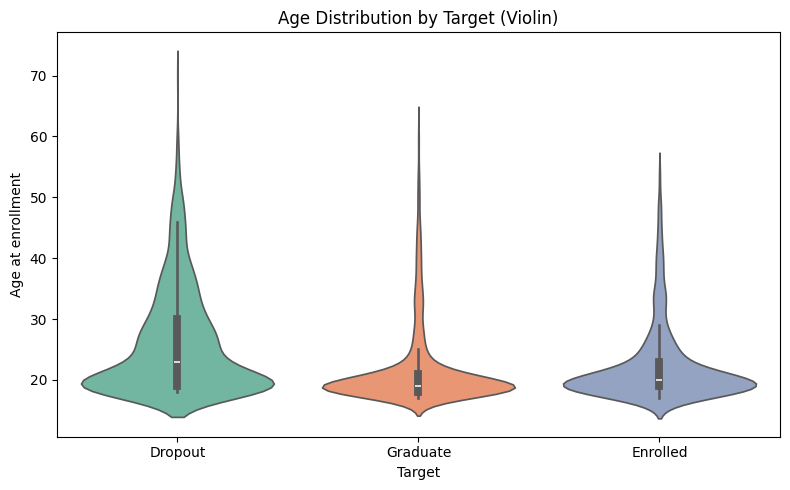

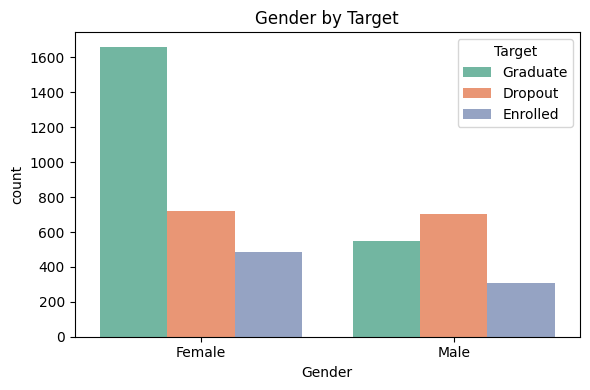

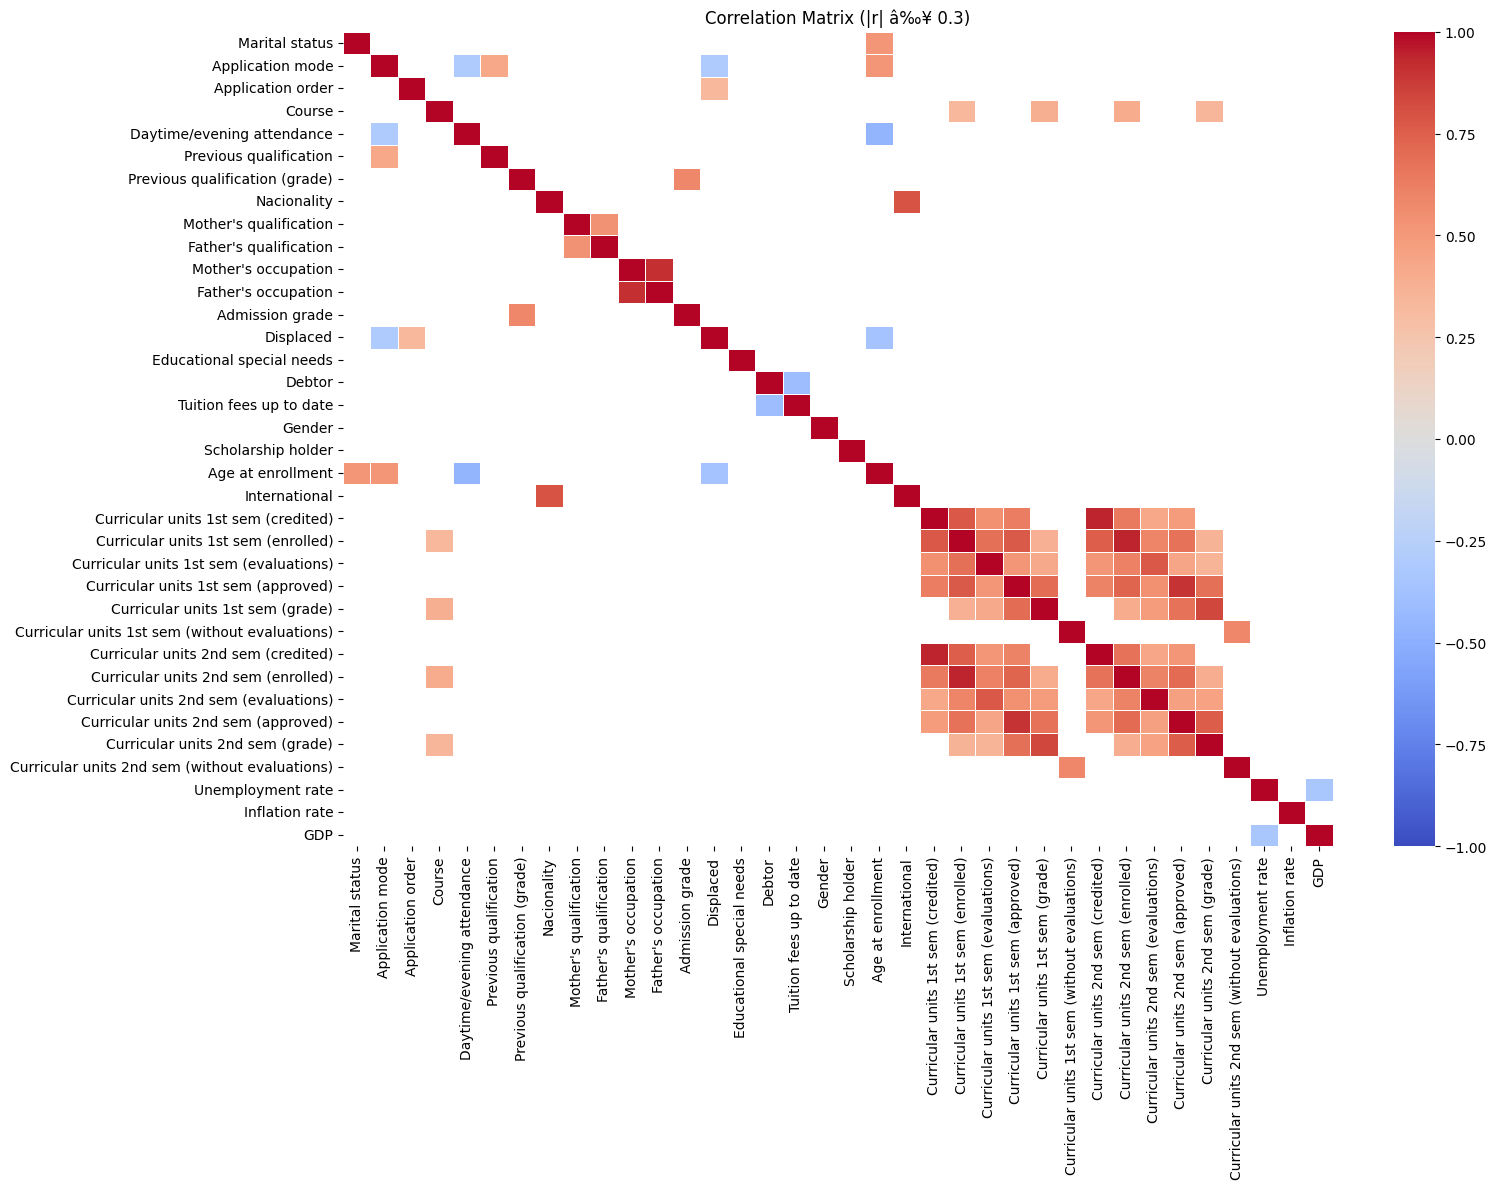

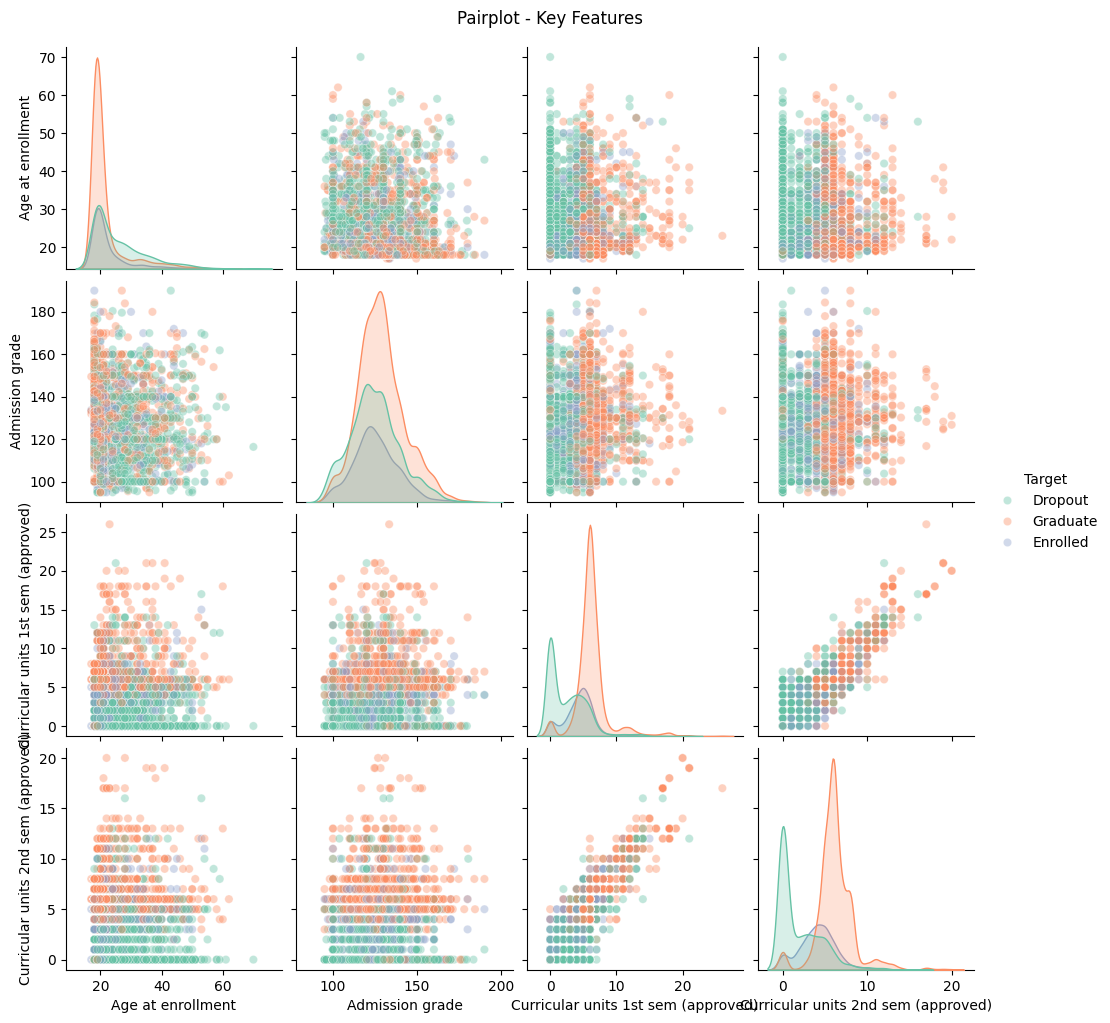

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ordner erstellen
os.makedirs('../results/exploration', exist_ok=True)

# Daten laden
df = pd.read_csv('../data/data.csv', sep=';')
df.columns = df.columns.str.strip()

# Ãœberblick
print(f"Shape: {df.shape}")
print(f"Fehlende Werte: {df.isnull().sum().sum()}")
print(f"\nKlassenverteilung:\n{df['Target'].value_counts()}")

# Klassenverteilung mit Prozentzahlen
fig, ax = plt.subplots(figsize=(7, 4))
counts = df['Target'].value_counts()
bars = ax.bar(counts.index, counts.values, color=['#2ecc71', '#e74c3c', '#3498db'])
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val} ({val/len(df)*100:.1f}%)', ha='center')
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../results/exploration/01_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


# Alter nach Zielklasse
plt.figure(figsize=(7, 4))
sns.boxplot(x='Target', y='Age at enrollment', data=df, palette='Set2')
plt.title('Age at Enrollment by Target')
plt.tight_layout()
plt.savefig('../results/exploration/02_age_by_target.png', dpi=300, bbox_inches='tight')
plt.show()

# Bestandene Kurse pro Semester nach Zielklasse
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x='Target', y='Curricular units 1st sem (approved)', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Approved Units - 1st Semester')
sns.boxplot(x='Target', y='Curricular units 2nd sem (approved)', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Approved Units - 2nd Semester')
plt.tight_layout()
plt.savefig('../results/exploration/03_approved_units.png', dpi=300, bbox_inches='tight')
plt.show()

# Noten pro Semester nach Zielklasse
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x='Target', y='Curricular units 1st sem (grade)', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Grade - 1st Semester')
sns.boxplot(x='Target', y='Curricular units 2nd sem (grade)', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Grade - 2nd Semester')
plt.tight_layout()
plt.savefig('../results/exploration/04_grades_by_target.png', dpi=300, bbox_inches='tight')
plt.show()

# SozioÃ¶konomische Faktoren: Schulden, Stipendium, StudiengebÃ¼hren
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Debtor', 'Scholarship holder', 'Tuition fees up to date']):
    sns.countplot(x=col, hue='Target', data=df, palette='Set2', ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig('../results/exploration/05_socioeconomic.png', dpi=300, bbox_inches='tight')
plt.show()

# Zulassungsnote nach Zielklasse
plt.figure(figsize=(7, 4))
sns.boxplot(x='Target', y='Admission grade', data=df, palette='Set2')
plt.title('Admission Grade by Target')
plt.tight_layout()
plt.savefig('../results/exploration/06_admission_grade.png', dpi=300, bbox_inches='tight')
plt.show()

# Violin Plot: Alter - zeigt Verteilung besser als Boxplot
plt.figure(figsize=(8, 5))
sns.violinplot(x='Target', y='Age at enrollment', data=df, palette='Set2')
plt.title('Age Distribution by Target (Violin)')
plt.tight_layout()
plt.savefig('../results/exploration/07_age_violin.png', dpi=300, bbox_inches='tight')
plt.show()

# Geschlecht nach Zielklasse
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', hue='Target', data=df, palette='Set2')
plt.title('Gender by Target')
plt.xticks([0, 1], ['Female', 'Male'])
plt.tight_layout()
plt.savefig('../results/exploration/08_gender_target.png', dpi=300, bbox_inches='tight')
plt.show()

# Korrelationsmatrix - nur starke Korrelationen (|r| >= 0.3)
plt.figure(figsize=(16, 12))
corr = df.select_dtypes(include='number').corr()
mask = corr.abs() < 0.3
sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=False, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix (|r| â‰¥ 0.3)')
plt.tight_layout()
plt.savefig('../results/exploration/09_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Pairplot der wichtigsten Features
key_features = ['Age at enrollment', 'Admission grade',
                'Curricular units 1st sem (approved)',
                'Curricular units 2nd sem (approved)', 'Target']
sns.pairplot(df[key_features], hue='Target', palette='Set2', plot_kws={'alpha': 0.4})
plt.suptitle('Pairplot - Key Features', y=1.02)
plt.savefig('../results/exploration/10_pairplot.png', dpi=300, bbox_inches='tight')
plt.show()




## Additional EDA: Planned Category and Correlation Views
This section adds the plan-specific figures for categorical dropout rates,
Top-5 academic feature violins, and the Top-10 correlation heatmap.

In [2]:
import sys
sys.path.insert(0, os.path.abspath('..'))
from src.data_loader import prepare_binary
from src.plots import (
    plot_correlation_heatmap,
    plot_dropout_rate_by_category,
    plot_top_features_violin,
)
df_binary = prepare_binary(df.copy())
binary_features = [
    'Tuition fees up to date',
    'Debtor',
    'Scholarship holder',
    'Gender',
    'Daytime/evening attendance',
    'Displaced',
]
fig = plot_dropout_rate_by_category(df_binary, binary_features)
plt.show()
top5_academic = [
    'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (evaluations)',
]
fig = plot_top_features_violin(df_binary, top5_academic)
plt.show()
top10_features = [
    'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (grade)',
    'Tuition fees up to date',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 1st sem (evaluations)',
    'Age at enrollment',
    'Scholarship holder',
    'Gender',
]
fig = plot_correlation_heatmap(df_binary, top10_features)
plt.show()

C:\Users\maxim\AppData\Local\Temp\ipykernel_796628\1883287322.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\maxim\AppData\Local\Temp\ipykernel_796628\1883287322.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\maxim\AppData\Local\Temp\ipykernel_796628\1883287322.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
